In [7]:
import matplotlib.pyplot as plt
import torch
import yaml
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel

import sys
sys.path.append("..")

In [8]:
with open("../config.yaml") as f:
    _cfg = yaml.safe_load(f)

embedding_names = [m["name"] for m in _cfg["models"]["embeddings"]]
embedding_dims = {m["name"]: m["embedding_dim"] for m in _cfg["models"]["embeddings"]}
print(f"Available embedding models: {embedding_names}")

Available embedding models: ['sentence-transformers/all-MiniLM-L6-v2', 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'sentence-transformers/all-mpnet-base-v2']


In [9]:
test_pairs = [
    (
        "Zakon o javnim cestama regullira izgradnju i održavanje cesta.",
        "Propisi o autocestama i brzim cestama u Republici Hrvatskoj.",
        1,
    ),
    (
        "Zakon o javnim cestama regullira izgradnju i održavanje cesta.",
        "Pravilnik o sigurnosti na cestama definira prometna pravila.",
        0,
    ),
    (
        "Gradsko vijeće donosi odluke o komunalnim djelatnostima.",
        "Općinsko vijeće upravlja lokalnom samoupravom.",
        1,
    ),
    (
        "Gradsko vijeće donosi odluke o komunalnim djelatnostima.",
        "Kazneni zakon propisuje kazne za prekršaje.",
        0,
    ),
    (
        "Pravo na zdravstvenu zaštitu ima svaki državljanin.",
        "Zdravstveno osiguranje pokriva troškove liječenja.",
        1,
    ),
    (
        "Pravo na zdravstvenu zaštitu ima svaki državljanin.",
        "Školski sustav osigurava obrazovanje za djecu.",
        0,
    ),
]

print(f"Loaded {len(test_pairs)} test pairs (3 similar, 3 dissimilar)")

Loaded 6 test pairs (3 similar, 3 dissimilar)


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def embed_text(text, tokenizer, model, device):
    enc = tokenizer([text], padding=True, truncation=True, max_length=512, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = model(**enc)
    emb = out.last_hidden_state.mean(dim=1)
    emb = F.normalize(emb, p=2, dim=1)
    return emb[0].cpu().numpy()

import torch.nn.functional as F

all_model_results = []

for model_name in embedding_names:
    print(f"\n{'='*60}\nEvaluating model: {model_name}\n{'='*60}\n")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model = model.to(device)
    model.eval()
    
    similarities = []
    labels = []
    
    for sent1, sent2, label in test_pairs:
        emb1 = embed_text(sent1, tokenizer, model, device)
        emb2 = embed_text(sent2, tokenizer, model, device)
        sim = cosine_similarity([emb1], [emb2])[0][0]
        similarities.append(sim)
        labels.append(label)
        print(f"  {label} | sim={sim:.4f} | {sent1[:40]}... / {sent2[:40]}...")
    
    similarities = np.array(similarities)
    labels = np.array(labels)
    
    similar_mask = labels == 1
    dissimilar_mask = labels == 0
    
    avg_sim = similarities.mean()
    avg_similar = similarities[similar_mask].mean()
    avg_dissimilar = similarities[dissimilar_mask].mean()
    separation = avg_similar - avg_dissimilar
    
    print(f"\nAvg similarity: {avg_sim:.4f}")
    print(f"Avg similar pairs: {avg_similar:.4f}")
    print(f"Avg dissimilar pairs: {avg_dissimilar:.4f}")
    print(f"Separation: {separation:.4f}")
    
    all_model_results.append({
        "model": model_name,
        "similarities": similarities,
        "labels": labels,
        "avg_sim": avg_sim,
        "avg_similar": avg_similar,
        "avg_dissimilar": avg_dissimilar,
        "separation": separation,
    })

Using device: cuda

Evaluating model: sentence-transformers/all-MiniLM-L6-v2



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 19426.81it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  1 | sim=0.5869 | Zakon o javnim cestama regullira izgradn... / Propisi o autocestama i brzim cestama u ...
  0 | sim=0.5965 | Zakon o javnim cestama regullira izgradn... / Pravilnik o sigurnosti na cestama defini...
  1 | sim=0.7418 | Gradsko vijeće donosi odluke o komunalni... / Općinsko vijeće upravlja lokalnom samoup...
  0 | sim=0.5532 | Gradsko vijeće donosi odluke o komunalni... / Kazneni zakon propisuje kazne za prekrša...
  1 | sim=0.6159 | Pravo na zdravstvenu zaštitu ima svaki d... / Zdravstveno osiguranje pokriva troškove ...
  0 | sim=0.6933 | Pravo na zdravstvenu zaštitu ima svaki d... / Školski sustav osigurava obrazovanje za ...

Avg similarity: 0.6313
Avg similar pairs: 0.6482
Avg dissimilar pairs: 0.6143
Separation: 0.0338

Evaluating model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18451.38it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  1 | sim=0.3394 | Zakon o javnim cestama regullira izgradn... / Propisi o autocestama i brzim cestama u ...
  0 | sim=0.8056 | Zakon o javnim cestama regullira izgradn... / Pravilnik o sigurnosti na cestama defini...
  1 | sim=0.7834 | Gradsko vijeće donosi odluke o komunalni... / Općinsko vijeće upravlja lokalnom samoup...
  0 | sim=0.1983 | Gradsko vijeće donosi odluke o komunalni... / Kazneni zakon propisuje kazne za prekrša...
  1 | sim=0.3637 | Pravo na zdravstvenu zaštitu ima svaki d... / Zdravstveno osiguranje pokriva troškove ...
  0 | sim=0.1703 | Pravo na zdravstvenu zaštitu ima svaki d... / Školski sustav osigurava obrazovanje za ...

Avg similarity: 0.4435
Avg similar pairs: 0.4955
Avg dissimilar pairs: 0.3914
Separation: 0.1041

Evaluating model: sentence-transformers/all-mpnet-base-v2



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20982.06it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  1 | sim=0.6557 | Zakon o javnim cestama regullira izgradn... / Propisi o autocestama i brzim cestama u ...
  0 | sim=0.5424 | Zakon o javnim cestama regullira izgradn... / Pravilnik o sigurnosti na cestama defini...
  1 | sim=0.6553 | Gradsko vijeće donosi odluke o komunalni... / Općinsko vijeće upravlja lokalnom samoup...
  0 | sim=0.5740 | Gradsko vijeće donosi odluke o komunalni... / Kazneni zakon propisuje kazne za prekrša...
  1 | sim=0.6889 | Pravo na zdravstvenu zaštitu ima svaki d... / Zdravstveno osiguranje pokriva troškove ...
  0 | sim=0.6539 | Pravo na zdravstvenu zaštitu ima svaki d... / Školski sustav osigurava obrazovanje za ...

Avg similarity: 0.6284
Avg similar pairs: 0.6666
Avg dissimilar pairs: 0.5901
Separation: 0.0765



════════════════════════════════════════════════════════════
VISUALIZATION: Separate subplots per metric + Similarity scatter
════════════════════════════════════════════════════════════



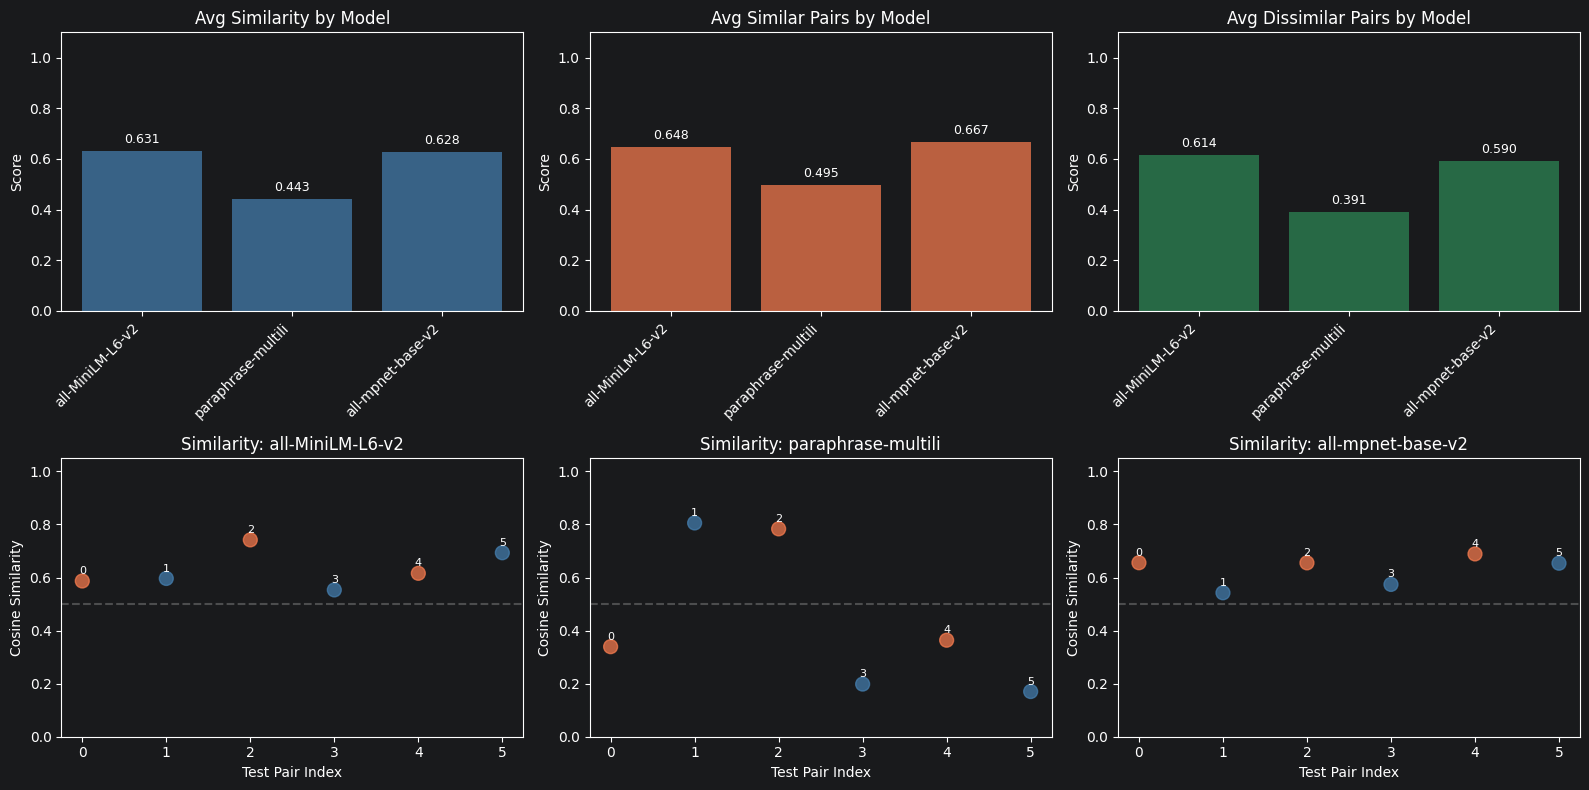

In [11]:
n_models = len(embedding_names)
model_names_short = [m.split("/")[-1][:18] for m in embedding_names]

print("\n" + "═" * 60)
print("VISUALIZATION: Separate subplots per metric + Similarity scatter")
print("═" * 60 + "\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

metrics = ["avg_sim", "avg_similar", "avg_dissimilar"]
titles = ["Avg Similarity", "Avg Similar Pairs", "Avg Dissimilar Pairs"]
colors = ["steelblue", "coral", "seagreen"]

for m_idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[0, m_idx]
    vals = [r[metric] for r in all_model_results]
    bars = ax.bar(range(n_models), vals, color=color, alpha=0.7)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(model_names_short, rotation=45, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_title(f"{title} by Model")
    ax.set_ylabel("Score")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", 
               ha="center", va="bottom", fontsize=9)

for idx, r in enumerate(all_model_results):
    ax = axes[1, idx]
    similarities = r["similarities"]
    labels = r["labels"]
    
    sim_vals = [similarities[i] for i in range(len(similarities))]
    colors = ["coral" if labels[i] == 1 else "steelblue" for i in range(len(labels))]
    x_vals = list(range(len(similarities)))
    
    ax.scatter(x_vals, sim_vals, c=colors, s=100, alpha=0.7)
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Test Pair Index")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"Similarity: {model_names_short[idx]}")
    ax.set_ylim(0, 1.05)
    
    for i, (sim, lbl) in enumerate(zip(similarities, labels)):
        ax.annotate(str(i), (i, sim), textcoords="offset points", xytext=(0,5), ha="center", fontsize=8)

for idx in range(len(all_model_results), 3):
    axes[1, idx].axis("off")

plt.tight_layout()
plt.show()